# Fitting Experimental Transmittance Spectrum using Basin Hopping with Bounds and Constraints. 

In previous works, I've compared different optimization methods for the fitting of Experimental Transmittance Spectrum. The best optimizer's Differential Evolution (based on Genetic Algorithm). 

## About Basin-Hopping (BH):

In applied mathematics, Basin-hopping is a global optimization technique that iterates by performing random perturbation of coordinates, performing local optimization, and accepting or rejecting new coordinates based on a minimized function value.[1] The algorithm was described in 1997 by David J. Wales and Jonathan Doye.[2] It is a particularly useful algorithm for global optimization in very high-dimensional landscapes, such as finding the minimum energy structure for molecules. The method is inspired from Monte-Carlo Minimization first suggested by Li and Scheraga.[3]

Sequential linear-quadratic programming (SLQP) is an iterative method for nonlinear optimization problems where objective function and constraints are twice continuously differentiable. Similarly to sequential quadratic programming (SQP), SLQP proceeds by solving a sequence of optimization subproblems. The difference between the two approaches is that:

in SQP, each subproblem is a quadratic program, with a quadratic model of the objective subject to a linearization of the constraints
in SLQP, two subproblems are solved at each step: a linear program (LP) used to determine an active set, followed by an equality-constrained quadratic program (EQP) used to compute the total step
This decomposition makes SLQP suitable to large-scale optimization problems, for which efficient LP and EQP solvers are available, these problems being easier to scale than full-fledged quadratic programs.

It may be considered related to, but distinct from, quasi-Newton methods.

## Used libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import time 
import numpy as np

## Transmittance Model

This is the Transmittance Model Equations given by the IIM following the Alonso's Model. 

In [2]:
# Archivo para obtener los valores de transmitancia del vidrio

#print(t_v[:,0][0])
def modelo_transmitancia(x, 
                         d, 
                         rugo_1, rugo_2, 
                         A, B, C, D, E, 
                         alpha, beta, gamma, 
                         ne):
    """
    x = longitud de onda
    d = espesor de la película
    t_vidrio = transmitancia del vidrio, valor experimental
    rugo_1 = rugosidad_1
    rugo_2 = rugosidad_2
    sellmeier = es el arreglo donde van a estar los coeficientes de la ecuacion de Sellmeier
    absorcion =  es el arreglo donde se van a guardar los coeficientes de la ecuacion de la absorcion
    ne = concentracion de electrones

    """
    # Constantes utilizadas

    c = 3e8 # Velocidad de la luz

    mu = 3.90e-4 # Movilidad

    df = pd.read_csv('../../experimental_samples/Background_data/TexpglassO.txt', sep = "\t", header = 0)
    t_v = df.values

    sellmeier = [A, B, C, D, E]

    absorcion = [alpha, beta, gamma]

    #ome_pla = np.sqrt(3182.61/0.417)*ne #Frecuencia de Plasma

    # Funciones

    def frecuencia(x):

        omega = 2 * np.pi * c * 1e9 / x

        return omega

    def gamma_f(x):

        gama = 2.8e11*x

        return gama

    def e1f_f(omega,gama,ne):

        return -(3182.61*ne)/(omega**2 + gama**2)

    def e2f_f(omega,gama,ne):

        return (3182.61 * ne * gama)/(omega * (omega**2 + gama**2))

    def e1b_f(x,sellmeier):
        # A = 2.0065
        # B = 1.574e6
        # C = 1e7
        # D = 1.5868
        # E = 260.63
        return sellmeier[0] + (sellmeier[1] * x**2)/(x**2 - sellmeier[2]**2 + 1e-6) + (sellmeier[3] * x**2)/(x**2 - sellmeier[4]**2 + 1e-6)

    def e2b_f(x):

        return 0.0

    def e1_f(e1f,e1b):

        return e1f + e1b

    def e2_f(e2f,e2b):

        return e2f + e2b

    def ng_f(t_v):
        """
        t_v transmitancia del vidrio
        """
        return (1/t_v) + np.sqrt(1/(t_v**2) - 1)

    def n_f(e1,e2):

        return (1/np.sqrt(2)) * np.sqrt(e1 + np.sqrt(e1**2 + e2**2)) + 1e-6

    def kapa_f(e1,e2):

        return (1/np.sqrt(2)) * np.sqrt(-e1 + np.sqrt(e1**2 + e2**2))

    def neff1_f(n):

        return np.sqrt((1/2) * (n**2 + 1))

    def T1_f(neff1,x,n,rugo_1):

        return np.exp(-0.5 * (2 * np.pi * rugo_1 * (neff1 - 1))**2 / x**2) * (n/1) * (4/(n + 1)**2)

    def T2_f(neff1,x,ng,n,rugo_2):

        return np.exp(-0.5 * (1/x**2) * (2 * np.pi * rugo_2 * (neff1 - 1))**2) * (ng/n) * 4 * (n**2) * (1/(n + ng)**2)

    def T3_f(ng):

        return (1/ng) * 4 * ng**2 * (1/(1 + ng)**2)

    def R1_f(n,x,rugo_1):

        return np.exp(-2 * (2 * np.pi * rugo_1 * n)**2 * (1/x)**2) * (n - 1)**2 * (1/(n + 1))**2

    def R2_f(n,x,ng,rugo_2):

        return np.exp(-2 * (2 * np.pi * rugo_2 * n)**2 * (1/x)**2) * (n - ng)**2 * (1/(n + ng))**2

    def R21_f(n,ng):

        return (n - ng)**2 * (1/(n + ng)**2)

    def R3_f(ng):

        return (ng - 1)**2 * (1/(ng + 1)**2)

    def phi_f(n,d,x):

        return 4 * np.pi * n * d * (1/x)

    def alfa_f(kapa,x,absorcion):
        #alpha_0 = 2.5e-3
        #beta = 9.8
        #lambdag = 363

        return kapa * 4 * np.pi * (1/x) + absorcion[0] * np.exp(1240 * absorcion[1] * ((1/x) - (1/absorcion[2])))

    def Tf_f(T1,T2,alfa,d,phi,R1,R2):

        exp1 = np.exp(np.clip(-alfa * d, -700, 700))
        exp2 = np.exp(np.clip(-2 * alfa * d, -700, 700))
        
        denominator = 1 - 2 * np.sqrt(R1 * R2) * np.cos(phi) * exp1 + R1 * R2 * exp2
        result = (T1 * T2) * exp1 / denominator

        return result
        #(T1 * T2) * np.exp(-alfa * d) / (1 - 2 * np.sqrt(R1 * R2) * np.cos(phi) * np.exp(-alfa * d) + R1 * R2 * np.exp(-2 * alfa * d))

    def T_f(T3,R21,R3,Tf):

        return 1.0 * ((T3 / (1 - R21 * R3)) * Tf * 100)

    def N_f(T1,R1):

        return T1 + k

    # Realizamos los calculos en cadena para obtener la transmitancia del modelo.

    omega = frecuencia(x) # Check 

    gama = gamma_f(x) # Check 

    e1f = e1f_f(omega,gama,ne)

    e2f = e2f_f(omega,gama,ne)

    e1b = e1b_f(x,sellmeier)

    e2b = e2b_f(x)

    e1 = e1_f(e1f,e1b)

    e2 = e2_f(e2f,e2b)

    ng = ng_f(t_v[:,1]) # Al ser un df, se transforma en un arreglo donde tomo solo la segunda columna

    #nswanep = nswanep(e1b[0])

    n = n_f(e1,e2)

    kapa = kapa_f(e1,e2)

    neff1 = neff1_f(n)

    T1 = T1_f(neff1,x,n,rugo_1)

    T2 = T2_f(neff1,x,ng,n,rugo_2)

    T3 = T3_f(ng)

    R1 = R1_f(n,x,rugo_1)

    R2 = R2_f(n,x,ng,rugo_2)

    R21 = R21_f(n,ng)

    R3 = R3_f(ng)

    phi = phi_f(n,d,x)

    alfa = alfa_f(kapa,x,absorcion)

    Tf = Tf_f(T1,T2,alfa,d,phi,R1,R2)

    T = T_f(T3,R21,R3,Tf)

    # Input   x, t_vidrio, d, rugo_1, rugo_2, sellmeier, absorcion, ne / x longitud de onda 
    # Output  T, d, rugo_1, rugo_2, sellmeier, absorcion, ne / T transmitancia 
    if np.isnan(T).any():
        print('NAN: T')
    
    return np.nan_to_num(T, nan=1e-6) #, d, rugo_1, rugo_2, sellmeier, absorcion, ne

## Experimental Samples

In [3]:
data = pd.read_pickle('../../results/dataframe_spectrum_thickness_145_final.pkl')
data.head()

,Nombre,Nombre-Arc,Espesor,Error,Error Porcentual,Espectro
0,ANZO32,ANZO32M,91.223787,12.300000,10.000000,"[[[0.071], [0.058], [0.055999], [0.08], [0.055..."
1,ANZO30,ANZO30M,167.256504,21.600000,10.256410,"[[[0.006999], [0.102], [0.029], [0.08], [0.035..."
2,ANZO35,ANZO35M,167.777276,21.100000,9.990530,"[[[0.066], [0.097], [0.023], [0.078], [0.047],..."
3,AZO3Min2,AZO3MI2M,224.029336,8.740362,3.166683,"[[[0.063], [0.091], [0.024], [0.066], [0.063],..."
4,AZO3Min,AZO3MINM,224.897289,14.052483,5.072915,"[[[0.071], [0.101], [0.002], [0.084], [0.04], ..."


In [4]:
data.shape

(145, 6)

## Algorithm

In [5]:
_name = 'basin_hopping_NonLinear'

In [6]:
from scipy.optimize import basinhopping

The function to minimize is Mean Square Error: 

In [7]:
def error(params, x, y):
    y_pred = modelo_transmitancia(x, *params)
    _ = np.mean( (y_pred - y)**2 )
    if np.isnan(_).any(): print('NAN in ERROR')
    return np.nan_to_num(_, nan=1e-6)

The constraint in the system corresponds to the reffractive index, this index must have a value in the range [1.8, 2.1]

In [8]:
from scipy.optimize import NonlinearConstraint

In [9]:
def refractive_index(x):
    A, B, C, D, E = x[3], x[4], x[5], x[6], x[7]
    _x = np.linspace(190e-9, 1101e-9, 911)
    n = np.sqrt( A + (B*_x**2)/(_x**2 - C**2 + 1e-6) + (D*_x**2)/(_x**2 - E**2 + 1e-6) )  # Get the n
    #print(n.shape)
    #print(np.mean(n))
    if np.isnan(n).any():
        print('NAN: refractive Index')
    
    return np.mean(np.nan_to_num(n, nan=1e-6))

In [10]:
nlc = NonlinearConstraint(refractive_index, 1.8, 2.1)

## Deactivate Warnings

In [11]:
import warnings

warnings.filterwarnings("ignore", message="delta_grad == 0.0.*")
warnings.filterwarnings("ignore", message=".*differential_evolution: the 'workers' keyword.*")
warnings.filterwarnings("ignore", message = 'invalid value encountered in multiply')
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Main

In [12]:
maes = [] # Used to save the fitting parameters

In [13]:
_tour = [i for i in range(1)] #data.shape[0])] # iteration list 
#_tour = [0]
len(_tour)

1

In [14]:
data.head()

,Nombre,Nombre-Arc,Espesor,Error,Error Porcentual,Espectro
0,ANZO32,ANZO32M,91.223787,12.300000,10.000000,"[[[0.071], [0.058], [0.055999], [0.08], [0.055..."
1,ANZO30,ANZO30M,167.256504,21.600000,10.256410,"[[[0.006999], [0.102], [0.029], [0.08], [0.035..."
2,ANZO35,ANZO35M,167.777276,21.100000,9.990530,"[[[0.066], [0.097], [0.023], [0.078], [0.047],..."
3,AZO3Min2,AZO3MI2M,224.029336,8.740362,3.166683,"[[[0.063], [0.091], [0.024], [0.066], [0.063],..."
4,AZO3Min,AZO3MINM,224.897289,14.052483,5.072915,"[[[0.071], [0.101], [0.002], [0.084], [0.04], ..."


In [15]:
pl = 0.5

In [16]:
pli = (1 - pl)
pls = (1 + pl)

In [17]:
t1 = time.time()

In [18]:
print('Ejecutando Basin Hopping en {} muestras...\n'.format(len(_tour)))
while len(_tour) != 0:
    
    for i in _tour:  # For all the samples
        x = np.arange(190, 1101, 1) # Set the x array
        y_data = data['Espectro'][i][0].squeeze() # Get the spectrum
        d = data['Espesor'][i] # Get the thickness
        d_error = data['Error'][i]
    
        # Set an initial values, the mean get by EGP-GA.
        # Not used 
        initial_guess = [d, 
                     30.6, 26.5,
                     2.0065, 1.574e6, 1e7, 1.5868, 260.63, 
                     5.0e-3, 1.0e1, 3.6e2, 
                     2.1e26 ]
        
        # Set the conditions (given by IIM), we allow n% error in the thickness measure
        bounds = [
            (d-d_error, d+d_error), 
            (pli*10, 150*pls), (pli*10, 150*pls),
            (pli*2, 4*pls), (pli*0.1e6, 1.6e6*pls), (pli*1e6, 10e6*pls), (pli*1, 3*pls), (pli*270, 280*pls), 
            (pli*0.5e-3, 10.0e-3*pls), (pli*5, 15*pls), (pli*350, 410*pls), (pli*1.0e26, 5.0e26*pls)
        ]

        minimizer_kwargs = {
            "method": "SLSQP",  
            "args": (x, y_data),
            "bounds": bounds,
            "constraints": nlc
        }
    
        try:
            print('Intentando ajustar muestra {}...'.format(i))
            _result_dv = basinhopping(error, 
                       initial_guess, 
                       minimizer_kwargs=minimizer_kwargs, 
                      )
            
            maes.append( [int(i)] + _result_dv.x.tolist() + [float(_result_dv.fun)] ) # save the parameters
            _tour.remove(i)

            print('--> Muestra {} terminada!'.format(i)) 
            print('-> Restantes: {}'.format(len(_tour)))
        
        except Exception as e: 
            # Depending in the parameters, we may get Error values
            print('Posponiendo muestra: {}\n'.format(i))
            print(e)
    


Ejecutando Basin Hopping en 1 muestras...

Intentando ajustar muestra 0...
--> Muestra 0 terminada!
-> Restantes: 0


In [19]:
t2 = time.time()

In [20]:
maes = np.array(maes) # Save as array 

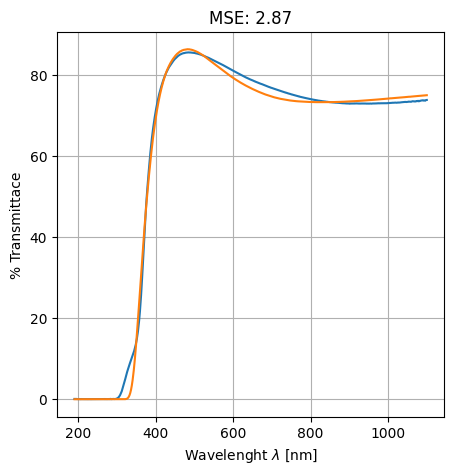

In [21]:
plt.figure(figsize = (5,5))
plt.plot(x, y_data)
plt.plot(x, modelo_transmitancia(x, *maes[-1][1:-1]))
plt.grid()
plt.xlabel(r'Wavelenght $\lambda$ [nm]')
plt.ylabel('% Transmittace')
plt.title('MSE: {:.2f}'.format(maes[-1][-1]))
plt.show()

The parameters are: Index, Thickness, R1, R2, Sellemier Coefficients (5), absorption coefficients (3), ne and MSE. 

In [22]:
maes[0]

array([0.00000000e+00, 1.03523787e+02, 8.19318799e+00, 1.05443858e+01,
       4.14011277e+00, 1.57399888e+06, 1.00000007e+07, 5.00000000e-01,
       1.35000000e+02, 5.81044659e-03, 4.85170732e+00, 3.71958605e+02,
       2.10000000e+26, 2.86654184e+00])

In [23]:
refractive_index(maes[0][1:])

np.float64(2.034726706642438)

In [24]:
maes.shape

(1, 14)

In [25]:
np.save('../../results/SciPy_IIM/{}_145F'.format(_name), maes)

In [26]:
print('Tiempo: ', t2-t1)

Tiempo:  38.82145833969116
